# Notebook 2: AI Alpha Generation (PyTorch Deep Learning & QuantLoss)

Trong notebook này, chúng ta sẽ huấn luyện mạng nơ-ron sâu (`AlphaMLP` với BatchNorm, Dropout, GELU) trên tập dữ liệu chuỗi thời gian chứng khoán Việt Nam:
1. Tách tập dữ liệu theo thời gian (Train, Validation, Test) để tránh Look-ahead Bias.
2. Định nghĩa hàm mất mát `QuantLoss` tối ưu cho Quant: kết hợp giữa **MSE Loss** và **Information Coefficient (IC) Loss**.
3. Huấn luyện mô hình và theo dõi sự hội tụ.
4. Đánh giá chỉ số IC Out-of-Sample và dự đoán vector $\mu$.


In [1]:
!git clone https://github.com/PTN2004/AI-Driven-Market-Neutral-Portfolio-Optimization.git
%cd AI-Driven-Market-Neutral-Portfolio-Optimization
!pip install -qr requirements.txt


Cloning into 'AI-Driven-Market-Neutral-Portfolio-Optimization'...
remote: Enumerating objects: 101, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (100/100), done.
remote: Total 101 (delta 0), reused 101 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (101/101), 3.22 MiB | 7.34 MiB/s, done.
/content/AI-Driven-Market-Neutral-Portfolio-Optimization
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.7/278.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 8.0 MB/s eta 0:00:00


In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path().resolve()))

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.utils.config import Config
from src.data_pipeline import DataFetcher, DataCleaner, FeatureEngineer, DataPreprocessor
from src.models import create_dataloaders, AlphaMLP, AlphaTrainer, AlphaPredictor, AlphaTFT

%matplotlib inline
sns.set_theme(style='whitegrid')


## 1. Chuẩn bị tập dữ liệu huấn luyện (Chronological Split)


In [3]:
fetcher = DataFetcher()
raw_data = fetcher.fetch_all()
cleaned_data = DataCleaner().clean_and_align(raw_data)
feature_data = FeatureEngineer().compute_all_features(cleaned_data)
preprocessor = DataPreprocessor()
normalized_data = preprocessor.normalize_features(feature_data)

master_df = preprocessor.prepare_tabular_dataset(normalized_data, Config.START_DATE, Config.END_DATE)
train_loader, val_loader, test_loader, test_df = create_dataloaders(master_df, batch_size=64)
print(f'Đã khởi tạo DataLoaders cho PyTorch. Kích thước tập Test: {len(test_df)} mẫu.')


[2026-07-30 15:43:09] [INFO] [DataFetcher]: Starting data ingestion for 51 symbols (2021-01-01 -> 2024-06-30)...


INFO:DataFetcher:Starting data ingestion for 51 symbols (2021-01-01 -> 2024-06-30)...


[2026-07-30 15:43:10] [INFO] [DataFetcher]: Successfully loaded data for 51 symbols.


INFO:DataFetcher:Successfully loaded data for 51 symbols.


[2026-07-30 15:43:10] [INFO] [DataCleaner]: Aligning 50 symbols to benchmark (913 trading days)...


...

[2026-07-30 15:43:11] [INFO] [DataPreprocessor]: Applying Sliding Window Z-score Normalization (window=120 days)...


INFO:DataPreprocessor:Applying Sliding Window Z-score Normalization (window=120 days)...


[2026-07-30 15:43:12] [INFO] [DataPreprocessor]: Normalization complete. No data leakage verified.


INFO:DataPreprocessor:Normalization complete. No data leakage verified.


Đã khởi tạo DataLoaders cho PyTorch. Kích thước tập Test: 12400 mẫu.


## 2. Khởi tạo & Huấn luyện mạng AlphaMLP với QuantLoss (MSE + IC)


In [8]:
model = AlphaTFT(input_dim=len(FeatureEngineer.get_feature_names()))
trainer = AlphaTrainer(model, lr=1e-3)

# Huấn luyện mô hình
history = trainer.fit(train_loader, val_loader, epochs=100)


[2026-07-30 15:52:26] [INFO] [AlphaTrainer]: Starting PyTorch training on cuda for 100 epochs...


INFO:AlphaTrainer:Starting PyTorch training on cuda for 100 epochs...


[2026-07-30 15:52:27] [INFO] [AlphaTrainer]: Epoch 01/100 - Train Loss: 0.4884 - Val Loss: 0.5108 - Val IC: -0.0067


INFO:AlphaTrainer:Epoch 01/100 - Train Loss: 0.4884 - Val Loss: 0.5108 - Val IC: -0.0067


[2026-07-30 15:52:34] [INFO] [AlphaTrainer]: Epoch 05/100 - Train Loss: 0.4674 - Val Loss: 0.5054 - Val IC: -0.0023


...

INFO:AlphaTrainer:Epoch 95/100 - Train Loss: 0.3903 - Val Loss: 0.4960 - Val IC: 0.0161


[2026-07-30 15:55:13] [INFO] [AlphaTrainer]: Epoch 100/100 - Train Loss: 0.3856 - Val Loss: 0.4992 - Val IC: 0.0117


INFO:AlphaTrainer:Epoch 100/100 - Train Loss: 0.3856 - Val Loss: 0.4992 - Val IC: 0.0117


[2026-07-30 15:55:13] [INFO] [AlphaTrainer]: Training completed.


INFO:AlphaTrainer:Training completed.


## 3. Trực quan hóa đường cong mất mát (Loss Curve) & Information Coefficient (IC)


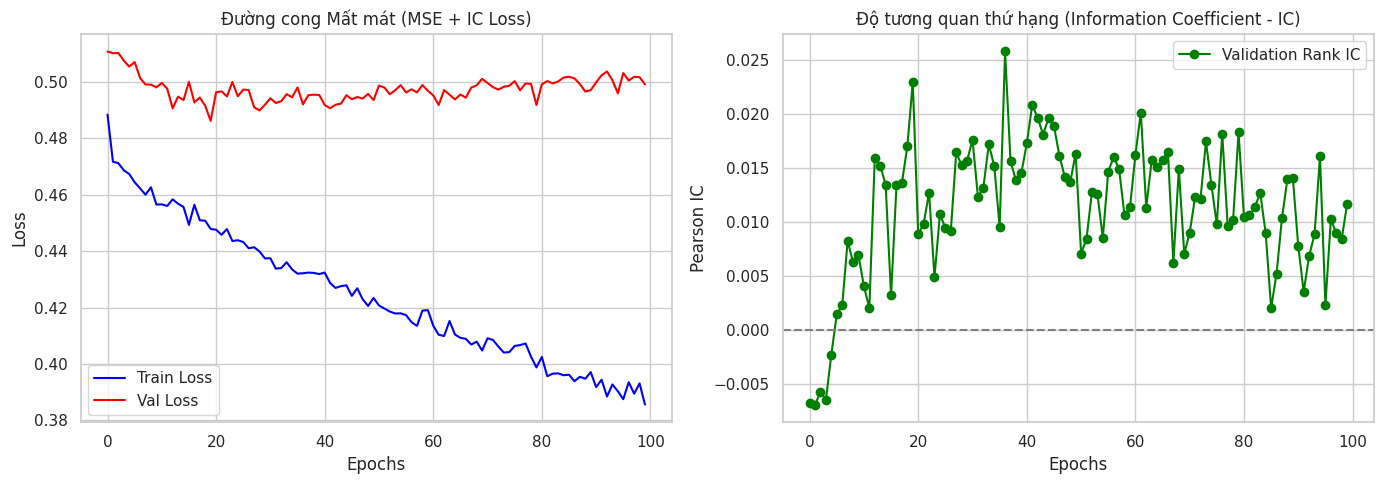

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red')
axes[0].set_title('Đường cong Mất mát (MSE + IC Loss)')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['val_ic'], label='Validation Rank IC', color='green', marker='o')
axes[1].axhline(0.0, color='gray', linestyle='--')
axes[1].set_title('Độ tương quan thứ hạng (Information Coefficient - IC)')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Pearson IC')
axes[1].legend()
plt.tight_layout()
plt.show()


## 4. Kiểm chứng suy luận Out-of-Sample (Predicting $\mu$)


In [ ]:
predictor = AlphaPredictor(model)
mu_preds = predictor.predict_all(test_df)
print('Kết quả dự báo lợi suất kỳ vọng mu trên tập Test:')
mu_preds[['date', 'symbol', 'close', 'target_ret_1d', 'predicted_mu']].tail(10)
